# Import libaries

In [184]:
import kagglehub
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk

from pathlib import Path
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


# 0. Load data

In [140]:
# Download latest version
path = kagglehub.dataset_download(
    "jp797498e/twitter-entity-sentiment-analysis",
    output_dir="data"
)

DATA_DIR = Path("data")

TRAIN_FILE = DATA_DIR / "twitter_training.csv"
VALIDATION_FILE = DATA_DIR / "twitter_validation.csv"

print(f"Training dataset: {TRAIN_FILE}")
print(f"Validation dataset: {VALIDATION_FILE}")

Training dataset: data\twitter_training.csv
Validation dataset: data\twitter_validation.csv


# 1. Data inspection

In [141]:
# Add the names of the columns in train and validation data frame
train_df = pd.read_csv(
    TRAIN_FILE,
    header=None,
    names=["id", "entity", "sentiment", "text"]
)

validation_df = pd.read_csv(
    VALIDATION_FILE,
    header=None,
    names=["id", "entity", "sentiment", "text"]
)

print("=" * 50)
print("DATA INSPECTION")
print("=" * 50)

# Dataset shape
print("\nTraining shape:", train_df.shape)
print("Validation shape:", validation_df.shape)

# Column information
print("\n" + "-" * 50)
print("COLUMN INFORMATION")
print("-" * 50)

column_info = pd.DataFrame({
    "Column": train_df.columns,
    "Data Type": train_df.dtypes.astype(str).values
})

print(f"\n{column_info}")

# Missing values
print("\n" + "-" * 50)
print("MISSING VALUES")
print("-" * 50)

print("\nTrain:")
missing_values_train = train_df.isnull().sum()

if missing_values_train.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values_train[missing_values_train > 0])

print("\nValidation:")
missing_values_val = validation_df.isnull().sum()

if missing_values_val.sum() == 0:
    print("No missing values found.")
else:
    print(missing_values_val[missing_values_val > 0])

# Duplicates
print("\n" + "-" * 50)
print("DUPLICATE ROWS")
print("-" * 50)

print("\nTrain:")
print(f"Number of duplicate rows: {train_df.duplicated().sum()}")

print("\nValidation:")
print(f"Number of duplicate rows: {validation_df.duplicated().sum()}")

print("\n" + "=" * 50)
print("INSPECTION COMPLETE")
print("=" * 50)

DATA INSPECTION

Training shape: (74682, 4)
Validation shape: (1000, 4)

--------------------------------------------------
COLUMN INFORMATION
--------------------------------------------------

      Column Data Type
0         id     int64
1     entity       str
2  sentiment       str
3       text       str

--------------------------------------------------
MISSING VALUES
--------------------------------------------------

Train:
text    686
dtype: int64

Validation:
No missing values found.

--------------------------------------------------
DUPLICATE ROWS
--------------------------------------------------

Train:
Number of duplicate rows: 2700

Validation:
Number of duplicate rows: 0

INSPECTION COMPLETE


## 1.1 Inspect missing values

In [142]:
train_df[train_df["text"].isna()].head(10)

,id,entity,sentiment,text
61,2411,Borderlands,Neutral,NaN
553,2496,Borderlands,Neutral,NaN
589,2503,Borderlands,Neutral,NaN
745,2532,Borderlands,Positive,NaN
1105,2595,Borderlands,Positive,NaN
1106,2595,Borderlands,Positive,NaN
2295,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2296,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2297,1602,CallOfDutyBlackopsColdWar,Irrelevant,NaN
2359,1613,CallOfDutyBlackopsColdWar,Irrelevant,NaN


### Info
There are **684** tweets with missing text, so they do not provide any useful information for the model. We will remove them later during the data cleaning stage.

## 1.2 Inspect duplicates

In [143]:
train_df[train_df.duplicated(keep=False)].sort_values("text").head(10)

,id,entity,sentiment,text
51507,10441,RedDeadRedemption(RDR),Negative,. . . Check out this clip! CGalvSports strea...
51504,10441,RedDeadRedemption(RDR),Negative,. . . Check out this clip! CGalvSports strea...
23580,4442,Google,Neutral,. - Android 9.0. . - Bezel-Less screen. . - D...
23583,4442,Google,Neutral,. - Android 9.0. . - Bezel-Less screen. . - D...
42270,10052,PlayerUnknownsBattlegrounds(PUBG),Neutral,. . pic.twitter.com/P1A5IeWDOa
42273,10052,PlayerUnknownsBattlegrounds(PUBG),Neutral,. . pic.twitter.com/P1A5IeWDOa
42096,10023,PlayerUnknownsBattlegrounds(PUBG),Negative,. . “No More Chicken Dinner: Why PUBG Ban in...
42099,10023,PlayerUnknownsBattlegrounds(PUBG),Negative,. . “No More Chicken Dinner: Why PUBG Ban in...
41832,1578,Battlefield,Positive,. . Exciting announcement in a few hours fami...
41835,1578,Battlefield,Positive,. . Exciting announcement in a few hours fami...


### Info
There are **2,700** duplicate tweets in the dataset. Since they do not provide additional information, we will remove them later during the data cleaning stage.

# 2. Evaluate data analysis
- Sentiment distribution
- Entity distribution
- Text length
- Sample tweets

## 2.1 Sentiment distribution

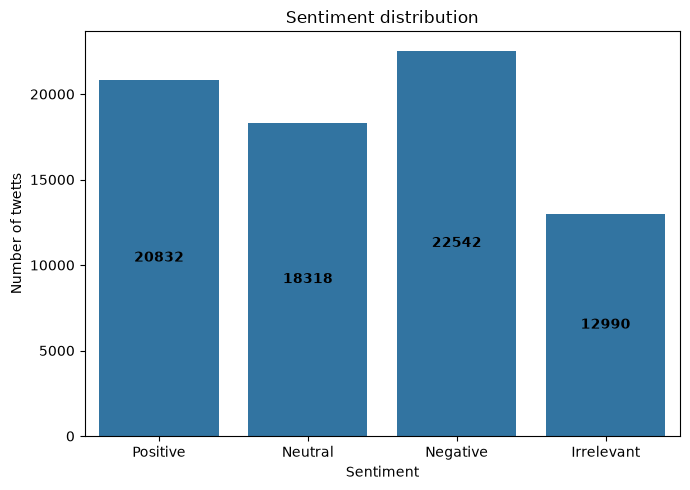

In [144]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=train_df,
    x="sentiment"
)

ax.bar_label(
    ax.containers[0],
    label_type="center",
    fontweight="bold"
)

plt.title("Sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of twetts")

plt.tight_layout()
plt.show()

### Observation
The sentiment classes are relatively well balanced. **Positive, Negative, and Neutral** contain a similar number of tweets, while **Irrelevant** is less frequent. However, the difference is not large enough to indicate a severe class imbalance problem.

## 2.2 Entity distribution

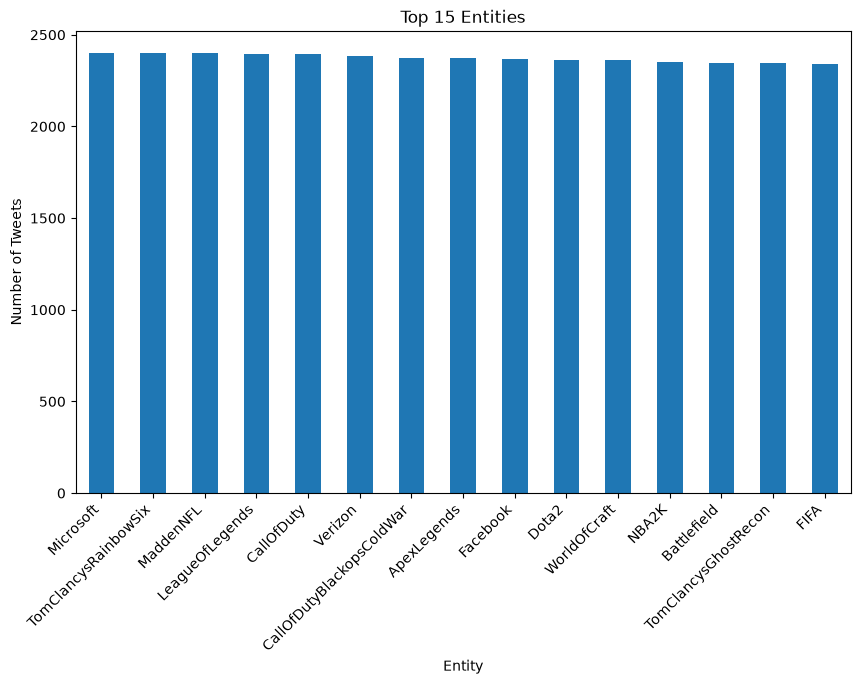

In [145]:
plt.figure(figsize=(10, 6))

train_df["entity"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Entities")
plt.xlabel("Entity")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")
plt.show()

### Observation
There are **almost no significant differences in the number of tweets across entities**, indicating that the dataset is relatively well balanced in terms of entity representation.

## 2.3 Text length

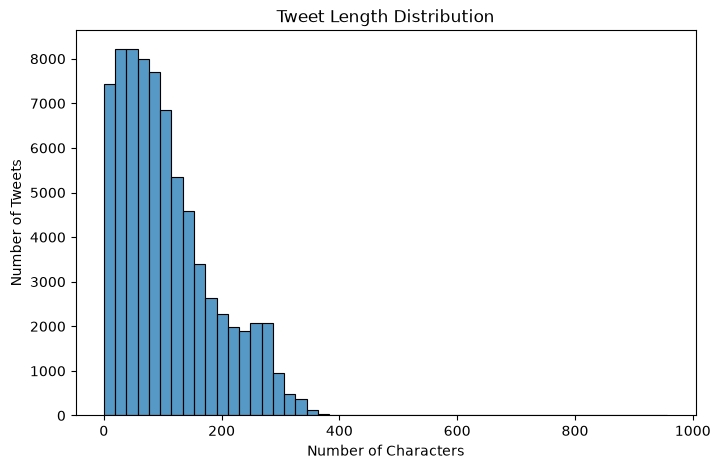

mean    107.78
std      79.84
min       0.00
max     957.00
Name: text_length, dtype: float64

In [146]:
train_df["text_length"] = train_df["text"].fillna("").str.len()

plt.figure(figsize=(8, 5))

sns.histplot(
    data=train_df,
    x="text_length",
    bins=50
)

plt.title("Tweet Length Distribution")
plt.xlabel("Number of Characters")
plt.ylabel("Number of Tweets")
plt.show()

train_df["text_length"].describe()
train_df["text_length"].agg(["mean", "std", "min", "max"]).round(2)

### Observation
Tweets have an average length of **108 characters**, but their lengths vary considerably. Most tweets are relatively short, although some significantly longer texts are present, with the maximum length reaching **957 characters**.

## 2.4 Sample tweets

In [147]:
for sentiment in train_df["sentiment"].unique():
    print(f"\n--- {sentiment} ---")
    display(
        train_df[train_df["sentiment"] == sentiment][
            ["entity", "text"]
        ].head(3)
    )


--- Positive ---


,entity,text
0,Borderlands,im getting on borderlands and i will murder yo...
1,Borderlands,I am coming to the borders and I will kill you...
2,Borderlands,im getting on borderlands and i will kill you ...



--- Neutral ---


,entity,text
12,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."
13,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."
14,Borderlands,"Rock-Hard La Varlope, RARE & POWERFUL, HANDSOM..."



--- Negative ---


,entity,text
24,Borderlands,the biggest dissappoinment in my life came out...
25,Borderlands,The biggest disappointment of my life came a y...
26,Borderlands,The biggest disappointment of my life came a y...



--- Irrelevant ---


,entity,text
102,Borderlands,Appreciate the (sonic) concepts / praxis Valen...
103,Borderlands,Appreciate the (sound) concepts / practices th...
104,Borderlands,Evaluate the (sound) concepts / concepts of Va...


# 3. Data cleaning
- Drop duplicates
- Drop missing values

In [148]:
# Train
train_df = train_df.drop_duplicates().copy()
train_df = train_df.dropna(subset=["text"]).copy()

# Validation
validation_df = validation_df.drop_duplicates().copy()
validation_df = validation_df.dropna(subset=["text"]).copy()

print("-" * 50)
print("Train")
print("-" * 50)

print("\nShape:", train_df.shape)
print("Missing values:", train_df.isna().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

print("\n")
print("-" * 50)
print("Validation")
print("-" * 50)

print("\nShape:", train_df.shape)
print("Missing values:", validation_df.isna().sum().sum())
print("Duplicates:", validation_df.duplicated().sum())

--------------------------------------------------
Train
--------------------------------------------------

Shape: (71656, 5)
Missing values: 0
Duplicates: 0


--------------------------------------------------
Validation
--------------------------------------------------

Shape: (71656, 5)
Missing values: 0
Duplicates: 0


# 4. Text Preprocessing
- **Basic text cleaning**: lowercase text, normalize whitespace, and replace common patterns such as URLs and user mentions with `[URL]` and `[USER]` tokens.
- **Extended text cleaning**: basic cleaning + removal of English stopwords.

## 4.1 Basic text cleaning

In [149]:
# Create new column to later compare the text
train_df["clean_text"] = train_df["text"].copy()

validation_df["clean_text"] = validation_df["text"].copy()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "[URL]", text)
    text = re.sub(r"@\w+", "[USER]", text)
    text = re.sub(r"\s+", " ", text)
    text = text.strip()
    return text

train_df["clean_text"] = train_df["clean_text"].apply(clean_text)

validation_df["clean_text"] = validation_df["clean_text"].apply(clean_text)

train_df[["text", "clean_text"]].head(10)

,text,clean_text
0,im getting on borderlands and i will murder yo...,im getting on borderlands and i will murder yo...
1,I am coming to the borders and I will kill you...,i am coming to the borders and i will kill you...
2,im getting on borderlands and i will kill you ...,im getting on borderlands and i will kill you ...
3,im coming on borderlands and i will murder you...,im coming on borderlands and i will murder you...
4,im getting on borderlands 2 and i will murder ...,im getting on borderlands 2 and i will murder ...
5,im getting into borderlands and i can murder y...,im getting into borderlands and i can murder y...
6,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...
7,So I spent a couple of hours doing something f...,so i spent a couple of hours doing something f...
8,So I spent a few hours doing something for fun...,so i spent a few hours doing something for fun...
9,So I spent a few hours making something for fu...,so i spent a few hours making something for fu...


## 4.2 Extended text cleaning => Remove Stopwords

In [150]:
# Create a new column
train_df["clean_text_extended"] = train_df["clean_text"].copy()
validation_df["clean_text_extended"] = validation_df["clean_text"].copy()

nltk.download("stopwords", quiet=True)

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

train_df["clean_text_extended"] = train_df["clean_text"].apply(remove_stopwords)

validation_df["clean_text_extended"] = validation_df["clean_text"].apply(remove_stopwords)

train_df.head(10)

,id,entity,sentiment,text,text_length,clean_text,clean_text_extended
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...,53,im getting on borderlands and i will murder yo...,"im getting borderlands murder ,"
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...,51,i am coming to the borders and i will kill you...,"coming borders kill all,"
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...,50,im getting on borderlands and i will kill you ...,"im getting borderlands kill all,"
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...,51,im coming on borderlands and i will murder you...,"im coming borderlands murder all,"
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...,57,im getting on borderlands 2 and i will murder ...,"im getting borderlands 2 murder all,"
5,2401,Borderlands,Positive,im getting into borderlands and i can murder y...,53,im getting into borderlands and i can murder y...,"im getting borderlands murder all,"
6,2402,Borderlands,Positive,So I spent a few hours making something for fu...,286,so i spent a few hours making something for fu...,spent hours making something fun. . . know hug...
7,2402,Borderlands,Positive,So I spent a couple of hours doing something f...,293,so i spent a couple of hours doing something f...,spent couple hours something fun... know huge ...
8,2402,Borderlands,Positive,So I spent a few hours doing something for fun...,139,so i spent a few hours doing something for fun...,spent hours something fun... know huge @ borde...
9,2402,Borderlands,Positive,So I spent a few hours making something for fu...,283,so i spent a few hours making something for fu...,spent hours making something fun. . . know hug...


# 5. TF-IDF (Term Frequency-Inverse Document Frequency)
**TF-IDF** is a technique that converts text into numerical features. It assigns higher weights to words that are important and distinctive within a tweet, while reducing the importance of very common words across the dataset. This allows machine learning models to work with text data.

In [151]:
# TF-IDF for Basic Cleaning
tfidf_clean = TfidfVectorizer()

X_train_clean = tfidf_clean.fit_transform(train_df["clean_text"])
X_validation_clean = tfidf_clean.transform(validation_df["clean_text"])

# TF-IDF for Extended Cleaning
tfidf_extended = TfidfVectorizer()

X_train_extended = tfidf_extended.fit_transform(train_df["clean_text_extended"])
X_validation_extended = tfidf_extended.transform(validation_df["clean_text_extended"])

# Target
y_train = train_df["sentiment"]
y_validation = validation_df["sentiment"]

print("Basic TF-IDF:", X_train_clean.shape)
print("Extended TF-IDF:", X_train_extended.shape)

Basic TF-IDF: (71656, 30660)
Extended TF-IDF: (71656, 30659)


### Info
Removing stopwords had almost no impact on the TF-IDF vocabulary size, suggesting that most removed stopwords were not represented as TF-IDF features.

# 6. Logistic Regression

In [157]:
# Clean
model_clean = LogisticRegression(max_iter=1000)

model_clean.fit(X_train_clean, y_train)

y_pred_clean = model_clean.predict(X_validation_clean)

# Extended
model_extended = LogisticRegression(max_iter=1000)

model_extended.fit(X_train_extended, y_train)

y_pred_extended = model_extended.predict(X_validation_extended)

# 7. Results

In [176]:
print("Basic Cleaning")
print(f"{(accuracy_score(y_validation, y_pred_clean)* 100):.2f}%\n")

print("Extended Cleaning")
print(f"{(accuracy_score(y_validation, y_pred_extended)* 100):.2f}%")

Basic Cleaning
90.30%

Extended Cleaning
90.60%


### Observation
There is almost no difference between the basic and extended cleaning approaches. Removing stopwords had a negligible impact on the final TF-IDF vocabulary, suggesting that most of these words were not represented as important features by the vectorizer.

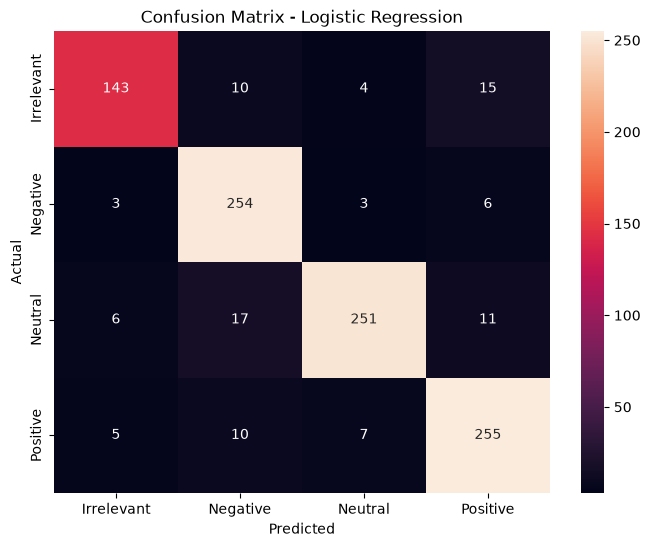

In [ ]:
cm = confusion_matrix(y_validation, y_pred_clean)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model_clean.classes_,
    yticklabels=model_clean.classes_
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### Summary
The model correctly classifies most of the tweets. The biggest difficulties occur with the **Irrelevant** class, which is frequently misclassified. The model also has some difficulty distinguishing between **Positive** and **Neutral**.